### Import

In [1]:
import os
import gc
import time
import scipy
import pickle 
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.ticker as ticker
from matplotlib import pyplot as plt 

from sklearn import metrics
from sklearn.utils import resample
from sklearn.metrics import auc
from sklearn.metrics import f1_score 
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

### Path

In [2]:
path_results = "./Results/"
path_data = "./Data/"

### Read Results

In [3]:
lstm = pd.read_csv(path_results + '60mins_Results.csv')
lstm_ff = pd.read_csv(path_results + '5mins_Results.csv')
llm = pd.read_csv(path_results + 'Processed_Results.csv')
lstm_llm = pd.read_csv(path_results + 'Processed_All_Results.csv')
lstm_llm_ff = pd.read_csv(path_results + 'TimeVariant.csv')

In [5]:
lstm = lstm[['patientunitstayid', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'unitdischargestatus']]
lstm_ff = lstm_ff[['patientunitstayid', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'unitdischargestatus']]
llm = llm[['patientunitstayid', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'unitdischargestatus']]
lstm_llm = lstm_llm[['patientunitstayid', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'unitdischargestatus']]
lstm_llm_ff = lstm_llm_ff[['patientunitstayid', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'unitdischargestatus']]

lstm.columns = ['patientunitstayid', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'unitdischargestatus']
lstm_ff.columns = ['patientunitstayid', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'unitdischargestatus']
llm.columns = ['patientunitstayid', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'unitdischargestatus']
lstm_llm.columns = ['patientunitstayid', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'unitdischargestatus']
lstm_llm_ff.columns = ['patientunitstayid', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'unitdischargestatus']

In [6]:
lstm.head(2)

### ROC

In [7]:
def ROC_curve(true_label, prediction_prob):
    
    AUC = roc_auc_score(true_label, prediction_prob)
    fpr, tpr, roc_thresholds = roc_curve(true_label, prediction_prob)

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(fpr, tpr, color='darkorange', lw=1.2, label='Model (AUC = {:.2f})'.format(AUC))
    plt.plot([0, 1], [0, 1], color='navy', lw=1.2, linestyle='--', label='Random (AUC = 0.50)')
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('False Positive Rate', fontsize=8)
    plt.ylabel('True Positive Rate', fontsize=8)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [8]:
def get_roc_ci(y_true, y_score):
    
    auc_scores = []
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)

    for j in range(1000):
        try:
            yte_true_b, yte_pred_b = resample(y_true, y_score, replace=True, random_state=j)
            fpr, tpr, _ = metrics.roc_curve(yte_true_b, yte_pred_b)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            tprs[-1][0] = 0.0
            auc_scores.append(metrics.roc_auc_score(yte_true_b, yte_pred_b))
            
        except Exception as e:
            continue
    
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    
    tprs_upper = np.minimum(mean_tpr + 1.96 * std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - 1.96 * std_tpr, 0)
    
    auc = roc_auc_score(y_true, y_score)
    
    return mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc

In [9]:
def plot_roc_with_ci(mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc_ci):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 6))
    
    plt.plot(mean_fpr, mean_tpr, color='blue', lw=2, label='Mean ROC (AUC = %0.2f)' % np.mean(auc_ci))
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=0.3)
    
    plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='red', label='Chance', alpha=0.8)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [10]:
mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc_ci = get_roc_ci(lstm['unitdischargestatus'], lstm['PREDICT_PROB'])

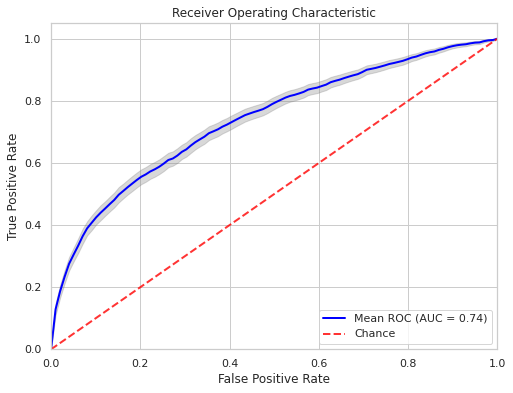

In [11]:
plot_roc_with_ci(mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc_ci)

### Precision-Recall

In [12]:
def PRC_REC_curve(true_label, prediction_prob):
    
    AP = average_precision_score(true_label, prediction_prob)
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob)
    no_skill = len(true_label[true_label == 1]) / len(true_label) 

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(recall, precision, color='darkorange', lw=1.2, label='Model (AP = {:.2f})'.format(AP))
    plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill (AP = {:.2f})'.format(no_skill))
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('Recall', fontsize=8)
    plt.ylabel('Precision', fontsize=8)
    plt.title('Precision-Recall Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [13]:
def get_prc_ci(y_true, y_score):
    
    prc_scores = []
    precisions = []
    recalls = []
    thresholds = np.linspace(0, 1, 100)

    for j in range(1000):
        try:
            yte_true_b, yte_pred_b = resample(y_true, y_score, replace=True, random_state=j)
            precision, recall, _ = metrics.precision_recall_curve(yte_true_b, yte_pred_b)
            prc_score = metrics.auc(recall, precision)
            prc_scores.append(prc_score)
            interp_precision = np.interp(thresholds, recall[::-1], precision[::-1])
            precisions.append(interp_precision)
        except Exception as e:

            continue

    mean_precision = np.mean(precisions, axis=0)
    std_precision = np.std(precisions, axis=0)

    precision_upper = np.minimum(mean_precision + 1.64 * std_precision, 1)
    precision_lower = np.maximum(mean_precision - 1.64 * std_precision, 0)
    
    ap = average_precision_score(y_true, y_score)
    
    return thresholds, mean_precision, precision_lower, precision_upper, ap

In [14]:
def plot_prc_with_ci(thresholds, mean_precision, precision_lower, precision_upper, prc_ci):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 6))

    plt.plot(thresholds, mean_precision, color='blue', lw=2, label='Mean PRC (AP = %0.2f)' % np.mean(prc_ci))
    plt.fill_between(thresholds, precision_lower, precision_upper, color='grey', alpha=0.3,)
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

In [15]:
thresholds, mean_precision, precision_lower, precision_upper, prc_ci = get_prc_ci(lstm['unitdischargestatus'], lstm['PREDICT_PROB'])

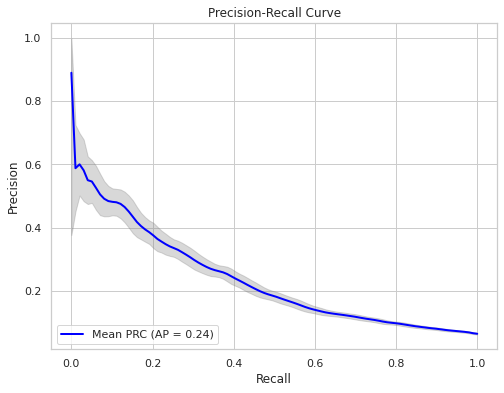

In [16]:
plot_prc_with_ci(thresholds, mean_precision, precision_lower, precision_upper, prc_ci)

### Performance Metrics

In [21]:
def Performance_Metrics(true_label, predicted_label, prediction_prob):
    
    TN, FP, FN, TP = confusion_matrix(true_label, predicted_label).ravel()

    ACC = (TP+TN)/(TP+FP+FN+TN)
    PRC = TP/(TP+FP)
    REC = TP/(TP+FN)
    F1M = (2*PRC*REC)/(PRC+REC)
    PPV = TP/(TP+FP)
    NPV = TN/(TN+FN)
    SEN = TP/(TP+FN)
    SPE = TN/(TN+FP) 
    FPR = FP/(FP+TN)
    FNR = FN/(TP+FN)
    FDR = FP/(TP+FP)

    AUC = roc_auc_score(true_label, prediction_prob)
    AP  = average_precision_score(true_label, prediction_prob)
    MCC = matthews_corrcoef(true_label, predicted_label)
    Brier = brier_score_loss(true_label, prediction_prob)
    
    print("ACC = " , np.round(ACC, 2)), print("PRC = " , np.round(PRC, 2))
    print("REC = " , np.round(REC, 2)), print("F1M = " , np.round(F1M, 2))
    print("PPV = " , np.round(PPV, 2)), print("NPV = " , np.round(NPV, 2))
    print("SEN = " , np.round(SEN, 2)), print("SPE = " , np.round(SPE, 2))
    print("FPR = " , np.round(FPR, 2)), print("FNR = " , np.round(FNR, 2))
    print("FDR = " , np.round(FDR, 2)), print("AUC = " , np.round(AUC, 2))
    print("AP  = " , np.round(AP,  2)), print("MCC = " , np.round(MCC, 2))
    print("Brier = " , np.round(Brier,  2))

In [22]:
def Performance_Metrics_CI(true_label, predicted_label, prediction_prob, n_bootstraps=1000, ci=95):
    
    metrics = {
        'ACC': [], 'PRC': [], 'REC': [], 'F1M': [], 'PPV': [],
        'NPV': [], 'SEN': [], 'SPE': [], 'FPR': [], 'FNR': [],
        'FDR': [], 'AUC': [], 'AP': [],  'MCC': [], 'BRR': []}
    
    for i in range(n_bootstraps):
        
        indices = resample(np.arange(len(true_label)), random_state=i)
        true_resampled = np.array(true_label)[indices]
        pred_resampled = np.array(predicted_label)[indices]
        prob_resampled = np.array(prediction_prob)[indices]
        
        TN, FP, FN, TP = confusion_matrix(true_resampled, pred_resampled).ravel()
        metrics['ACC'].append((TP + TN) / (TP + FP + FN + TN))
        metrics['PRC'].append(TP / (TP + FP) if TP + FP > 0 else 0)
        metrics['REC'].append(TP / (TP + FN) if TP + FN > 0 else 0)
        metrics['F1M'].append((2 * metrics['PRC'][-1] * metrics['REC'][-1]) / (metrics['PRC'][-1] + metrics['REC'][-1]) if metrics['PRC'][-1] + metrics['REC'][-1] > 0 else 0)
        metrics['PPV'].append(TP / (TP + FP) if TP + FP > 0 else 0)
        metrics['NPV'].append(TN / (TN + FN) if TN + FN > 0 else 0)
        metrics['SEN'].append(metrics['REC'][-1])
        metrics['SPE'].append(TN / (TN + FP) if TN + FP > 0 else 0)
        metrics['FPR'].append(FP / (FP + TN) if FP + TN > 0 else 0)
        metrics['FNR'].append(FN / (TP + FN) if TP + FN > 0 else 0)
        metrics['FDR'].append(FP / (TP + FP) if TP + FP > 0 else 0)
        metrics['AUC'].append(roc_auc_score(true_resampled, prob_resampled))
        metrics['AP'].append(average_precision_score(true_resampled, prob_resampled))
        metrics['MCC'].append(matthews_corrcoef(true_resampled, pred_resampled))
        metrics['BRR'].append(brier_score_loss(true_resampled, prob_resampled))

    ci_bounds = {}
    for key in metrics:
        lower = np.percentile(metrics[key], (100 - ci) / 2)
        upper = np.percentile(metrics[key], 100 - (100 - ci) / 2)
        mean  = np.mean(metrics[key])
        ci_bounds[key] = (mean, lower, upper)

    for metric, values in ci_bounds.items():
        print(f"{metric} = {values[0]:.3f} ({values[1]:.3f}-{values[2]:.3f})")

In [23]:
Performance_Metrics_CI(lstm['unitdischargestatus'], lstm['PREDICT_LABEL'], lstm['PREDICT_PROB'])

ACC = 0.510 (0.504-0.515)
PRC = 0.098 (0.093-0.102)
REC = 0.800 (0.780-0.818)
F1M = 0.174 (0.167-0.181)
PPV = 0.098 (0.093-0.102)
NPV = 0.973 (0.970-0.975)
SEN = 0.800 (0.780-0.818)
SPE = 0.490 (0.484-0.495)
FPR = 0.510 (0.505-0.516)
FNR = 0.200 (0.182-0.220)
FDR = 0.902 (0.898-0.907)
AUC = 0.737 (0.723-0.750)
AP = 0.236 (0.216-0.256)
MCC = 0.143 (0.132-0.152)
BRR = 0.297 (0.294-0.299)


In [24]:
Performance_Metrics_CI(lstm_ff['unitdischargestatus'], lstm_ff['PREDICT_LABEL'], lstm_ff['PREDICT_PROB'])

ACC = 0.531 (0.525-0.536)
PRC = 0.102 (0.097-0.107)
REC = 0.800 (0.781-0.818)
F1M = 0.181 (0.173-0.189)
PPV = 0.102 (0.097-0.107)
NPV = 0.974 (0.971-0.976)
SEN = 0.800 (0.781-0.818)
SPE = 0.512 (0.506-0.518)
FPR = 0.488 (0.482-0.494)
FNR = 0.200 (0.182-0.219)
FDR = 0.898 (0.893-0.903)
AUC = 0.744 (0.731-0.756)
AP = 0.245 (0.225-0.266)
MCC = 0.154 (0.144-0.164)
BRR = 0.274 (0.271-0.276)


In [25]:
Performance_Metrics_CI(llm['unitdischargestatus'], llm['PREDICT_LABEL'], llm['PREDICT_PROB'])

ACC = 0.711 (0.706-0.717)
PRC = 0.158 (0.151-0.165)
REC = 0.800 (0.780-0.818)
F1M = 0.264 (0.253-0.274)
PPV = 0.158 (0.151-0.165)
NPV = 0.981 (0.979-0.983)
SEN = 0.800 (0.780-0.818)
SPE = 0.705 (0.700-0.711)
FPR = 0.295 (0.289-0.300)
FNR = 0.200 (0.182-0.220)
FDR = 0.842 (0.835-0.849)
AUC = 0.835 (0.825-0.845)
AP = 0.331 (0.309-0.353)
MCC = 0.265 (0.253-0.276)
BRR = 0.211 (0.208-0.214)


In [26]:
Performance_Metrics_CI(lstm_llm['unitdischargestatus'], lstm_llm['PREDICT_LABEL'], lstm_llm['PREDICT_PROB'])

ACC = 0.851 (0.847-0.855)
PRC = 0.276 (0.264-0.288)
REC = 0.800 (0.782-0.817)
F1M = 0.410 (0.396-0.424)
PPV = 0.276 (0.264-0.288)
NPV = 0.984 (0.982-0.986)
SEN = 0.800 (0.782-0.817)
SPE = 0.855 (0.851-0.859)
FPR = 0.145 (0.141-0.149)
FNR = 0.200 (0.183-0.218)
FDR = 0.724 (0.712-0.736)
AUC = 0.905 (0.899-0.911)
AP = 0.452 (0.427-0.476)
MCC = 0.413 (0.399-0.426)
BRR = 0.169 (0.166-0.172)


In [27]:
Performance_Metrics_CI(lstm_llm_ff['unitdischargestatus'], lstm_llm_ff['PREDICT_LABEL'], lstm_llm_ff['PREDICT_PROB'])

ACC = 0.821 (0.817-0.825)
PRC = 0.237 (0.228-0.248)
REC = 0.800 (0.781-0.818)
F1M = 0.366 (0.353-0.378)
PPV = 0.237 (0.228-0.248)
NPV = 0.983 (0.982-0.985)
SEN = 0.800 (0.781-0.818)
SPE = 0.823 (0.818-0.827)
FPR = 0.177 (0.173-0.182)
FNR = 0.200 (0.182-0.219)
FDR = 0.763 (0.752-0.772)
AUC = 0.889 (0.882-0.895)
AP = 0.418 (0.393-0.442)
MCC = 0.371 (0.358-0.383)
BRR = 0.222 (0.219-0.226)


### Plotting Probability Distributions

In [28]:
def plot_kde(data, labels):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6), dpi=80)
    sns.kdeplot(data[labels == 0], label='Survived', shade=True)
    sns.kdeplot(data[labels == 1], label='Deceased', shade=True)
    plt.title('Predicted Probability Distribution by Outcome', fontsize=14)
    plt.xlabel('Predicted Probability', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.legend()
    plt.show()

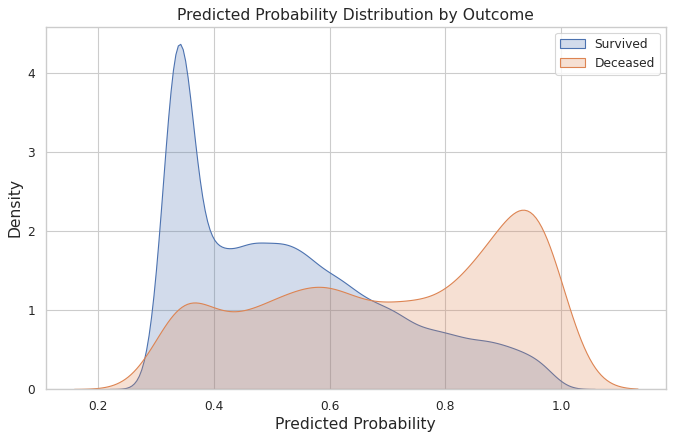

In [29]:
plot_kde(lstm['PREDICT_PROB'], lstm['unitdischargestatus'])

In [30]:
def plot_violin(data, labels):
    
    sns.set(style="whitegrid", context="talk")
    plt.figure(figsize=(10, 6), dpi=80)
    ax = sns.violinplot(x=labels, y=data, palette="muted", split=True)
    ax.set_xticklabels(['Survived', 'Deceased'])
    plt.title('Predicted Probability Distribution by Outcome', fontsize=14)
    plt.xlabel('Outcome', fontsize=14)
    plt.ylabel('Predicted Probability', fontsize=14)
    plt.show()

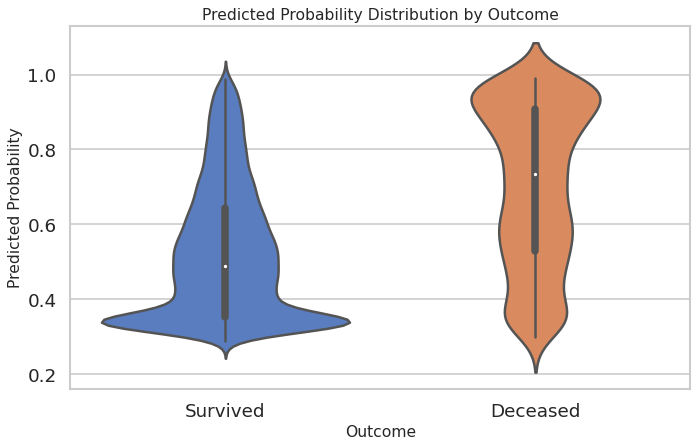

In [31]:
plot_violin(lstm['PREDICT_PROB'], lstm['unitdischargestatus'])

In [32]:
def plot_box(data, labels):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6), dpi=80)
    ax = sns.boxplot(x=labels, y=data, palette="muted")
    ax.set_xticklabels(['Survived', 'Deceased'], fontsize= 14)
    plt.title('Predicted Probability Distribution by Outcome', fontsize=14)
    plt.xlabel('Outcome', fontsize=14)
    plt.ylabel('Predicted Probability', fontsize=14)
    plt.show()

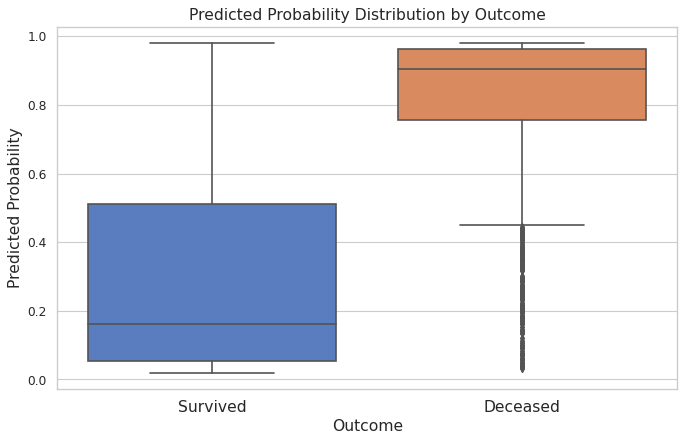

In [33]:
plot_box(lstm_llm['PREDICT_PROB'], lstm_llm['unitdischargestatus'])

### Plot ROC All

In [34]:
lstm_mean_fpr, lstm_mean_tpr, lstm_tprs_lower, lstm_tprs_upper, lstm_auc_ci = get_roc_ci(lstm['unitdischargestatus'], lstm['PREDICT_PROB'])
lstm_ff_mean_fpr, lstm_ff_mean_tpr, lstm_ff_tprs_lower, lstm_ff_tprs_upper, lstm_ff_auc_ci = get_roc_ci(lstm_ff['unitdischargestatus'], lstm_ff['PREDICT_PROB'])
llm_mean_fpr, llm_mean_tpr, llm_tprs_lower, llm_tprs_upper, llm_auc_ci = get_roc_ci(llm['unitdischargestatus'], llm['PREDICT_PROB'])
lstm_llm_mean_fpr, lstm_llm_mean_tpr, lstm_llm_tprs_lower, lstm_llm_tprs_upper, lstm_llm_auc_ci = get_roc_ci(lstm_llm['unitdischargestatus'], lstm_llm['PREDICT_PROB'])
lstm_llm_ff_mean_fpr, lstm_llm_ff_mean_tpr, lstm_llm_ff_tprs_lower, lstm_llm_ff_tprs_upper, lstm_llm_ff_auc_ci = get_roc_ci(lstm_llm_ff['unitdischargestatus'], lstm_llm_ff['PREDICT_PROB'])

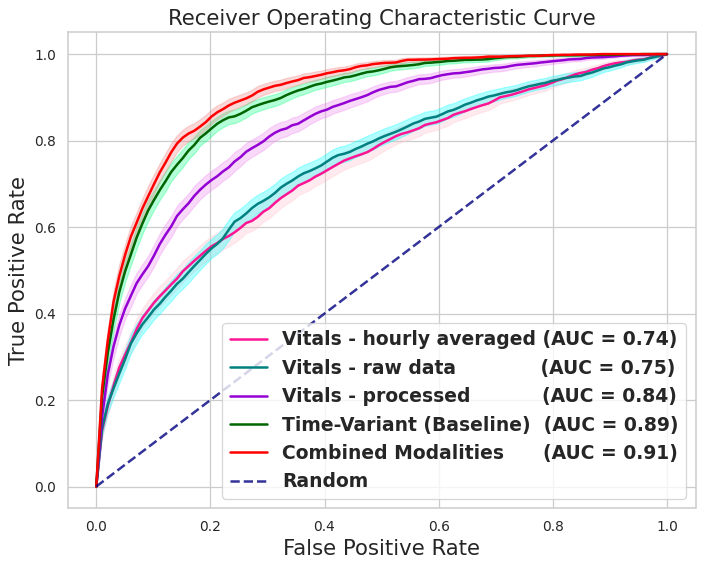

In [87]:
sns.set(style="whitegrid")
plt.figure(figsize=(9, 7), dpi=90)

plt.plot(lstm_mean_fpr, lstm_mean_tpr, color='deeppink', lw=2, label='Vitals - hourly averaged (AUC = %0.2f)' % np.mean(lstm_auc_ci))
plt.fill_between(lstm_mean_fpr, lstm_tprs_lower, lstm_tprs_upper, color='pink', alpha=0.3)

plt.plot(lstm_ff_mean_fpr, lstm_ff_mean_tpr, color='teal', lw=2, label='Vitals - raw data             (AUC = %0.2f)' % (np.mean(lstm_ff_auc_ci)))
plt.fill_between(lstm_ff_mean_fpr, lstm_ff_tprs_lower, lstm_ff_tprs_upper, color='aqua', alpha=0.3)

plt.plot(llm_mean_fpr, llm_mean_tpr, color='darkviolet', lw=2, label='Vitals - processed           (AUC = %0.2f)' % (np.mean(llm_auc_ci)))
plt.fill_between(llm_mean_fpr, llm_tprs_lower, llm_tprs_upper, color='violet', alpha=0.3)

plt.plot(lstm_llm_ff_mean_fpr, lstm_llm_ff_mean_tpr, color='darkgreen', lw=2, label='Time-Variant (Baseline)  (AUC = %0.2f)' % np.mean(lstm_llm_ff_auc_ci))
plt.fill_between(lstm_llm_ff_mean_fpr, lstm_llm_ff_tprs_lower, lstm_llm_ff_tprs_upper, color='springgreen', alpha=0.3)

plt.plot(lstm_llm_mean_fpr, lstm_llm_mean_tpr, color='red', lw=2, label='Combined Modalities      (AUC = %0.2f)' % (np.mean(lstm_llm_auc_ci)))
plt.fill_between(lstm_llm_mean_fpr, lstm_llm_tprs_lower, lstm_llm_tprs_upper, color='lightcoral', alpha=0.3)

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='navy', label='Random', alpha=0.8)

# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=17)
plt.ylabel('True Positive Rate', fontsize=17)
plt.title('Receiver Operating Characteristic Curve', fontsize=17)
# plt.legend(loc="lower right", fontsize=15)
legend = plt.legend(fontsize=15)  
for text in legend.get_texts():
    text.set_fontweight('bold')  
plt.show()

### Plot Precision-Recall All

In [36]:
lstm_thresholds, lstm_mean_precision, lstm_precision_lower, lstm_precision_upper, lstm_prc_ci = get_prc_ci(lstm['unitdischargestatus'], lstm['PREDICT_PROB'])
lstm_ff_thresholds, lstm_ff_mean_precision, lstm_ff_precision_lower, lstm_ff_precision_upper, lstm_ff_prc_ci = get_prc_ci(lstm_ff['unitdischargestatus'], lstm_ff['PREDICT_PROB'])
llm_thresholds, llm_mean_precision, llm_precision_lower, llm_precision_upper, llm_prc_ci = get_prc_ci(llm['unitdischargestatus'], llm['PREDICT_PROB'])
lstm_llm_thresholds, lstm_llm_mean_precision, lstm_llm_precision_lower, lstm_llm_precision_upper, lstm_llm_prc_ci = get_prc_ci(lstm_llm['unitdischargestatus'], lstm_llm['PREDICT_PROB'])
lstm_llm_ff_thresholds, lstm_llm_ff_mean_precision, lstm_llm_ff_precision_lower, lstm_llm_ff_precision_upper, lstm_llm_ff_prc_ci = get_prc_ci(lstm_llm_ff['unitdischargestatus'], lstm_llm_ff['PREDICT_PROB'])

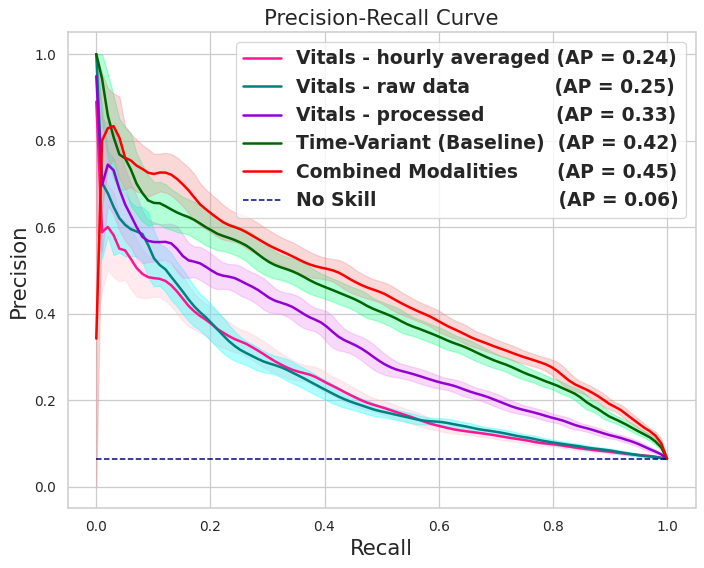

In [86]:
sns.set(style="whitegrid")
plt.figure(figsize=(9, 7), dpi=90)

plt.plot(lstm_thresholds, lstm_mean_precision, color='deeppink', lw=2, label='Vitals - hourly averaged (AP = %0.2f)' % np.mean(lstm_prc_ci))
plt.fill_between(lstm_thresholds, lstm_precision_lower, lstm_precision_upper, color='pink', alpha=0.3,)

plt.plot(lstm_ff_thresholds, lstm_ff_mean_precision, color='teal', lw=2, label='Vitals - raw data             (AP = %0.2f)' % (np.mean(lstm_ff_prc_ci)))
plt.fill_between(lstm_ff_thresholds, lstm_ff_precision_lower, lstm_ff_precision_upper, color='aqua', alpha=0.3,)

plt.plot(llm_thresholds, llm_mean_precision, color='darkviolet', lw=2, label='Vitals - processed           (AP = %0.2f)' % np.mean(llm_prc_ci))
plt.fill_between(llm_thresholds, llm_precision_lower, llm_precision_upper, color='violet', alpha=0.3,)

plt.plot(lstm_llm_ff_thresholds, lstm_llm_ff_mean_precision, color='darkgreen', lw=2, label='Time-Variant (Baseline)  (AP = %0.2f)' % np.mean(lstm_llm_ff_prc_ci))
plt.fill_between(lstm_llm_ff_thresholds, lstm_llm_ff_precision_lower, lstm_llm_ff_precision_upper, color='springgreen', alpha=0.3,)

plt.plot(lstm_llm_thresholds, lstm_llm_mean_precision, color='red', lw=2, label='Combined Modalities      (AP = %0.2f)' % np.mean(lstm_llm_prc_ci))
plt.fill_between(lstm_llm_thresholds, lstm_llm_precision_lower, lstm_llm_precision_upper, color='lightcoral', alpha=0.3,)

true_label = np.array(lstm['unitdischargestatus'])

no_skill = len(true_label[true_label == 1]) / len(true_label)
plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill                            (AP = {:.2f})'.format(no_skill))

plt.xlabel('Recall', fontsize=17)
plt.ylabel('Precision', fontsize=17)
plt.title('Precision-Recall Curve', fontsize=17)
# plt.legend(loc="best", fontsize=14)
legend = plt.legend(fontsize=15)  
for text in legend.get_texts():
    text.set_fontweight('bold') 
plt.show()